In [237]:
using Plots,JLD2,LinearAlgebra

In [238]:
Nx=24
Ny=24
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.09
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [239]:
st=load("test.jld2")
   

Dict{String, Any} with 14 entries:
  "Eelec"          => -2.48045
  "grad"           => [0.000981524, -0.000512402, 0.000220237, 0.00023623, 0.00…
  "spectrum"       => [-4.77672, -4.76678, -4.75665, -4.73665, -4.73433, -4.725…
  "max_record"     => 0.410472
  "average_record" => 0.209265
  "record_cal"     => Vector{Any}[[-2.37354, -2.37955, -2.382, -2.38448, -2.382…
  "orbital_id"     => [1 25 … 529 553; 2 26 … 530 554; … ; 23 47 … 551 575; 24 …
  "phonon_id"      => [1 25 … 529 553; 2 26 … 530 554; … ; 23 47 … 551 575; 24 …
  "phonon_coor"    => [0.24145, -0.236293, 0.194001, 0.0252915, -0.234377, 0.22…
  "FL"             => 1.58734
  "ave_npa"        => 720.0
  "E_total"        => -2.39009
  "Egap"           => 0.412979
  "free_energy"    => -2.39014

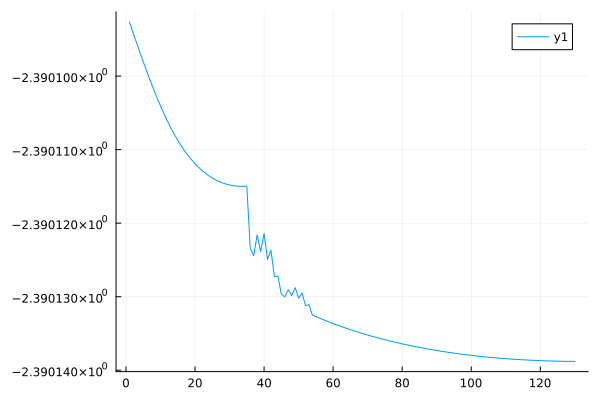

In [240]:
plot(st["record_cal"][1][100:end])

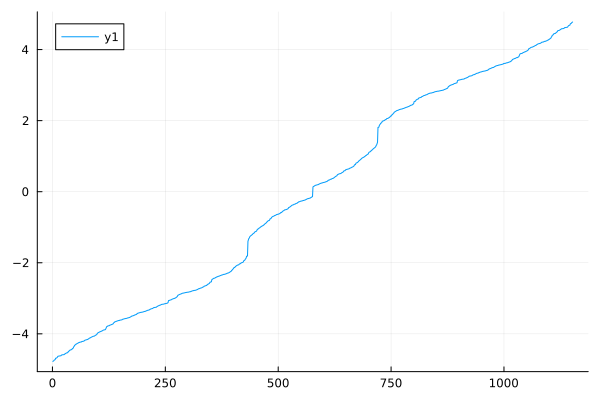

In [241]:
plot(sort(st["spectrum"]))

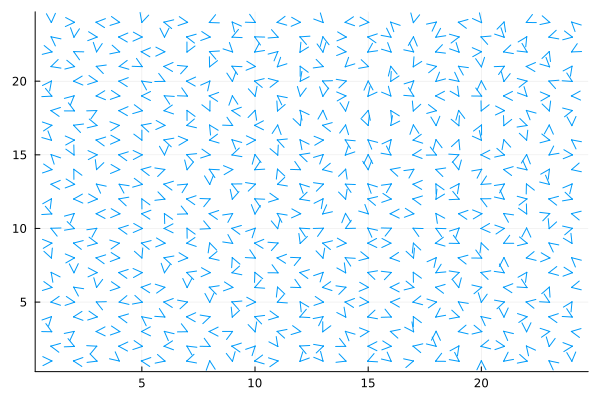

In [242]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(0.1*vec(dis_x),0.1*vec(dis_y)))




In [243]:
#savefig(p1,"quiverplot.png")

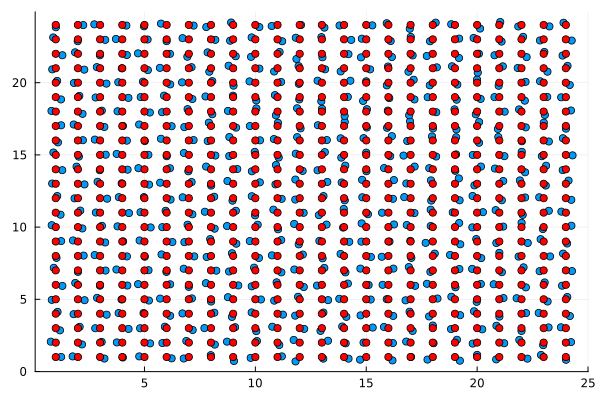

In [244]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [245]:
#savefig(p2,"atomplot.png")

In [246]:
sort(vec(dis_y)-vec(atom_y))

576-element Vector{Float64}:
 -0.3590266493435763
 -0.304075038856052
 -0.30353716652133045
 -0.29969841380328077
 -0.2894248958648795
 -0.28759930809331635
 -0.27463625902322164
 -0.2657087245984684
 -0.2640905386535586
 -0.2623373259541779
  ⋮
  0.27855477409924134
  0.2807454491885082
  0.2816075579440316
  0.2909471877065801
  0.29649505353732764
  0.2965942956857788
  0.2969679325897481
  0.31830150265270873
  0.3715207157057776

In [247]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

576-element Vector{Float64}:
  1.5979115899935918
  2.049445981082737
  2.2051496610928245
  2.875980363476249
  3.0866936373779073
  3.317017409670742
  3.689462451160276
  3.725039581164222
  4.086261219117984
  4.1400382962485525
  ⋮
 32.00449674456026
 32.05391813227612
 32.07120511536967
 32.35709176845612
 32.367878300665204
 32.38327472136209
 33.347007848095004
 33.37687459392827
 33.975360791577096

In [248]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

19.013817841706043

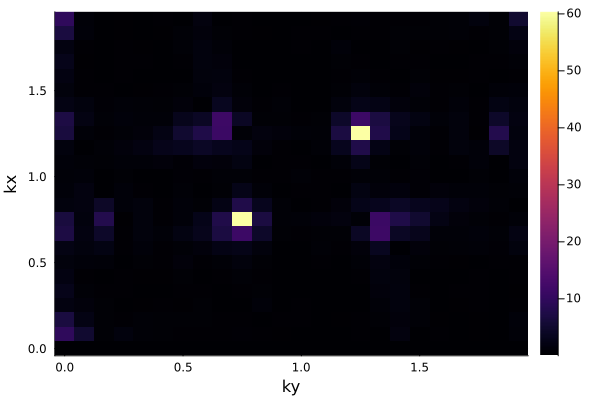

In [249]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [250]:
sort(vec(abs.(Fourier_mode_x)))

576-element Vector{Float64}:
  2.5637101847120046e-15
  2.834300427753141e-15
  3.927413949611491e-15
  1.0394507974086664e-14
  1.0868893329791554e-14
  1.1167925237560456e-14
  1.6200138708564483e-14
  1.6258988777394677e-14
  1.654002815229372e-14
  1.65452743476464e-14
  ⋮
  9.518572304323536
 11.099166687443647
 11.099166687443688
 11.274800451327275
 11.274800451327387
 11.410384371585732
 11.410384371585739
 60.36145756574406
 60.3614575657441

In [251]:
findmax(abs.(Fourier_mode_x))

(60.3614575657441, CartesianIndex(10, 10))

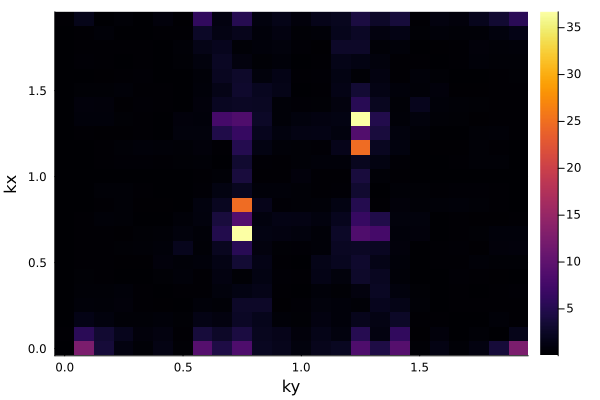

In [252]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [253]:
findmax(abs.(Fourier_mode_y))

(36.69584999329537, CartesianIndex(9, 10))

In [254]:
Fourier_mode_y[8,14]

0.07446785339661559 - 0.43275546079639976im

In [255]:
Fourier_mode_x[8,14]

-0.14923009886210442 + 0.5107557584070302im

In [256]:
Fourier_mode_y[14,8]

-0.09964457884687694 + 0.3337141808419785im

In [257]:
Fourier_mode_x[14,8]

0.23719413320675986 - 1.110001974731477im

In [258]:
Fourier_mode_y[8,8]

0.27493079909095786 + 0.18848135731178497im

In [259]:
Fourier_mode_x[8,8]

-0.7788509662073836 - 0.8149439810659859im